In [1]:
import os
import numpy as np
import pandas as pd
import nrrd
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.lines import Line2D

- Responsive-neuron stimulus selectivity map
- Co-active neuron map
- Tricaine emergence region-fill map and effect-size map

In [2]:
analysis_dir = '/Volumes/raid_126TB/Mikrofluidik/2025/aligned_ants_selected/neurons/analysis'
outdir = f'{analysis_dir}/brain_maps'
os.makedirs(outdir, exist_ok=True)

use_detrended = True
variant = 'detrended' if use_detrended else 'original'

compounds = ['control', 'PTZ', 'Tricaine']
colors = {'control': 'steelblue', 'PTZ': 'firebrick', 'Tricaine': '#7CA82A'}
division_colors = {'Telencephalon': 'tab:red', 'Diencephalon': 'orange',
                   'Mesencephalon': 'mediumseagreen', 'Rhombencephalon': 'dodgerblue'}

# Z-Brain atlas
zbrain_reference = '/Users/koester_lab/Documents/Z-Brain/Elavl3-H2BRFP_z_brain.nrrd'
zbrain_masks = '/Users/koester_lab/Documents/Z-Brain/z_brain_regions'
mask_shift_x = 10                        # atlas masks shift left 10 px
dx_um = 0.798                            # Z-Brain pixel size (x, y), µm
dz_um = 2.0                              # Z-Brain z-spacing, µm
zstretch = dz_um / dx_um                 # ~2.5: stretch the lateral depth axis to in-plane pixels

# Selectivity map: hue = the neuron's stimulus, opacity = effect size
# unbiased shuffled draw order — all fish and all responsive neurons pooled
alpha_range = (0.12, 0.98)

# Co-active neuron map: one representative fish per condition, sequential colormap
# only neurons with coactivity >= coact_floor drawn
map_fish = {'control': 'fish09', 'PTZ': 'fish11', 'Tricaine': 'fish02'}
coact_cmap = 'magma'
coact_floor = 0.2

# Tricaine emergence fill: only the top_n regions by emergence index are filled
emergence_top_n = 15
min_neurons_per_region = 10  # same as in responsive neurons notebook

# Tricaine effect-size map: diverging colormap of the signed effect size (blue = suppressed, red = excited)
# symmetric ceiling at the effect_vmax_pct percentile
effect_cmap = 'RdBu_r'
effect_vmax_pct = 95
effect_alpha = 0.80


**Load analysis csv files**

In [3]:
responsive = pd.read_csv(f'{analysis_dir}/responsive_neurons/responsive_per_neuron_{variant}.csv')
coactivity = pd.read_csv(f'{analysis_dir}/seizure_frequency/coactivity_per_neuron_{variant}.csv')
emergence_map = pd.read_csv(f'{analysis_dir}/comparison_recovery/tricaine_emergence_region_map_{variant}.csv')
region_counts = pd.read_csv(f'{analysis_dir}/responsive_neurons/responsive_per_fish_region_{variant}.csv')  # number of neurons per region

**Z-Brain reference projection and mask outlines**

In [4]:
def load_nrrd(path):
    vol, header = nrrd.read(path)
    return np.asarray(vol).T, header

In [5]:
# masks are drawn on Ref20131120pt14pl2.nrrd (terk) but image doesn't look so nice
# for registration I used Elavl3-H2BRFP_z_brain.nrrd but masks don't fit perfectly
# shift masks slightly so they fit better
def shift_left(mask, dx):
    if dx == 0:
        return mask.copy()
    shifted = np.zeros_like(mask)
    shifted[:, :mask.shape[1] - dx] = mask[:, dx:]
    return shifted

In [6]:
# dorsal view: z max projection, lateral view: x max projection
def reference_projections():

    ref, _ = load_nrrd(zbrain_reference)
    dorsal = np.max(ref, axis=0).astype(np.float32)
    lateral = np.max(ref, axis=2).astype(np.float32)
    
    return dorsal / (dorsal.max() or 1.0), lateral / (lateral.max() or 1.0)

In [7]:
# masks in dorsal view are shifted slightly (see above), in lateral view not
def division_outline_masks():

    masks = {}
    for division in division_colors:
        vol, _ = load_nrrd(f'{zbrain_masks}/{division} -.nrrd')
        b = vol > 0
        masks[division] = (shift_left(np.max(b, axis=0), mask_shift_x), np.max(b, axis=2))
        
    return masks

In [8]:
# dorsal and lateral width of the pair, needed for the figsize
def pair_widths(dorsal, lateral):

    ylim = (dorsal.shape[0] - 1, 0)  # y high, y low
    dorsal_xlim = (0, dorsal.shape[1] - 1)  # x low, x high
    lateral_xlim = (0, lateral.shape[0] * zstretch)  # z low, z high
    
    return (dorsal_xlim[1] - dorsal_xlim[0], lateral_xlim[1] - lateral_xlim[0],
            ylim[0] - ylim[1])

In [9]:
def view_coords(view, dots):
    if view == 'dorsal':
        return dots['x'].to_numpy(float), dots['y'].to_numpy(float)
    return dots['z'].to_numpy(float) * zstretch, dots['y'].to_numpy(float)

In [10]:
# Z-brain max projection and mask outlines
def draw_anatomy(ax, view, dorsal, lateral, masks, ylim=None, xlim=None, scalebar=False,
                 brain_dim=0.75, outline_lw=4.0, image=True):
    if image:
        if view == 'dorsal':
            img = dorsal
            extent = [-0.5, img.shape[1] - 0.5, img.shape[0] - 0.5, -0.5]
        else:
            img = lateral.T  # from (z, y) to (y, z)
            extent = [-0.5, img.shape[1] * zstretch - 0.5, img.shape[0] - 0.5, -0.5]
        ax.imshow(img * brain_dim, cmap='gray', vmin=0, vmax=1, extent=extent,
                  interpolation='nearest', aspect='equal', zorder=0)
    if masks:
        for division, pair in masks.items():
            if view == 'dorsal':
                ax.contour(pair[0].astype(np.uint8), levels=[0.5],
                           colors=[division_colors[division]], linewidths=outline_lw,
                           alpha=0.95, zorder=5)
            else:
                m = pair[1].T  # from (z, y) to (y, z)
                ax.contour(np.arange(m.shape[1]) * zstretch, np.arange(m.shape[0]),
                           m.astype(np.uint8), levels=[0.5],
                           colors=[division_colors[division]], linewidths=outline_lw,
                           alpha=0.95, zorder=5)
    ax.set_adjustable('box')
    if xlim:
        ax.set_xlim(*xlim)
    if ylim:
        ax.set_ylim(*ylim)

    # 100 µm bar, lower left
    if scalebar:
        px = 100 / dx_um
        y0 = ax.get_ylim()[0] - 24
        x0 = ax.get_xlim()[0] + 24
        ax.plot([x0, x0 + px], [y0, y0], color='white', lw=3, solid_capstyle='butt')
        
    ax.set_axis_off()

In [11]:
def add_colorbar(fig, host_ax, sm, label, rect=[1.06, 0.30, 0.09, 0.35], ticks=None):

    cax = host_ax.inset_axes(rect)
    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label(label, fontsize=12, labelpad=10)
    cbar.ax.tick_params(labelsize=10)
    
    if ticks is not None:
        cbar.set_ticks(ticks)
        
    return cbar

In [12]:
# needed for all brain maps below
dorsal, lateral = reference_projections()
div_masks = division_outline_masks()

### Responsive neuron selectivity map  
Responsive neurons colored by their stimulus (color) and effect size (opacity); separate figures for excited and suppressed neurons.  
All fish and all responsive neurons are pooled and randomly selected for the visualization.

In [13]:
# with pair_titles=True just 'excited' and 'suppressed' as figure titles, otherwise also dorsal and lateral annotation
def plot_selectivity_map(dots, path_to_save=None, s=9, px_in=0.0085, seed=0, pair_titles=True):

    up, down = dots[dots.up], dots[dots.down]
    av = dots['resp_z'].abs().to_numpy()
    vmin, vmax = float(np.percentile(av, 1)), float(np.percentile(av, 99))
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    a_lo, a_hi = alpha_range

    def dot_rgba(d):
        # color = condition, alpha = effect size
        n = np.clip(norm(d['resp_z'].abs().to_numpy()), 0, 1)
        rgba = np.empty((len(d), 4), np.float32)
        rgba[:, :3] = [mcolors.to_rgb(colors[c]) for c in d['compound']]
        rgba[:, 3] = a_lo + (a_hi - a_lo) * n
        return rgba

    ylim = (dorsal.shape[0] - 1, 0)
    dorsal_xlim = (0, dorsal.shape[1] - 1)
    lateral_xlim = (0, lateral.shape[0] * zstretch)
    dw, lw, yh = pair_widths(dorsal, lateral)
    gap = 0.5 * (dw + lw) * 0.18
    widths = [dw, lw, gap, dw, lw]
    
    fig, axs = plt.subplots(1, 5, figsize=(sum(widths) * px_in, yh * px_in * 1.14),
                            gridspec_kw={'width_ratios': widths, 'wspace': 0.0})
    
    panels = [(axs[0], 'dorsal', up, True), (axs[1], 'lateral', up, False),
              (axs[3], 'dorsal', down, False), (axs[4], 'lateral', down, False)]
    axs[2].set_axis_off()
    
    for ax, view, d, scalebar in panels:
        draw_anatomy(ax, view, dorsal, lateral, div_masks,
                     ylim, dorsal_xlim if view == 'dorsal' else lateral_xlim, scalebar)
        if len(d):
            d = d.iloc[np.random.default_rng(seed).permutation(len(d))]  # unbiased draw order
            sx, sy = view_coords(view, d)
            ax.scatter(sx, sy, s=s, c=dot_rgba(d), linewidths=0, marker='o',
                       rasterized=True, zorder=4)
    if pair_titles:
        x_center = (dw + lw) / (2 * dw)
        axs[0].set_title('excited', x=x_center, fontsize=30, pad=10)
        axs[3].set_title('suppressed', x=x_center, fontsize=30, pad=10)
    else:
        axs[0].set_title(f'excited — dorsal (n={len(up)})', fontsize=26)
        axs[1].set_title('lateral', fontsize=26)
        axs[3].set_title(f'suppressed — dorsal (n={len(down)})', fontsize=26)
        axs[4].set_title('lateral', fontsize=26)

    condition_handles = [Line2D([0], [0], marker='o', color='none',
                                markerfacecolor=colors[c], markersize=14, label=c)
                         for c in compounds]
    alpha_handles = [Line2D([0], [0], marker='o', color='none', markerfacecolor='0.75',
                            alpha=a, markersize=14, label=lab)
                     for a, lab in [(a_lo, f'{vmin:.0f} SD'),
                                    (0.5 * (a_lo + a_hi), ''), (a_hi, f'≥{vmax:.0f} SD')]]
    division_handles = [Line2D([0], [0], color=division_colors[d], lw=4, label=d)
                        for d in division_colors]
    
    leg1 = axs[4].legend(handles=condition_handles, loc='upper left',
                         bbox_to_anchor=(1.01, 1.0), frameon=False, fontsize=24,
                         title='stimulus', title_fontsize=24)
    axs[4].add_artist(leg1)
    leg2 = axs[4].legend(handles=alpha_handles, loc='upper left', bbox_to_anchor=(1.01, 0.70),
                         frameon=False, fontsize=24, title='response z-score',
                         title_fontsize=24)
    axs[4].add_artist(leg2)
    axs[4].legend(handles=division_handles, loc='upper left', bbox_to_anchor=(1.01, 0.36),
                  frameon=False, fontsize=22, title='division', title_fontsize=24)

    if path_to_save:
        fig.savefig(f'{path_to_save}.pdf', bbox_inches='tight', dpi=300)
        fig.savefig(f'{path_to_save}.png', bbox_inches='tight', dpi=200)
        
    return fig, axs

In [14]:
# per fish summary of responsive neurons and how many of them are excited or suppressed
map_counts = (responsive.groupby(['compound', 'fish'])
              .agg(n_responsive=('resp_z', 'size'), n_excited=('up', 'sum'),
                   n_suppressed=('down', 'sum'))
              .reset_index())
map_counts.to_csv(f'{outdir}/selectivity_map_counts_{variant}.csv', index=False)
map_counts

,compound,fish,n_responsive,n_excited,n_suppressed
0,PTZ,fish04,18513,15569,2944
1,PTZ,fish08,29487,24595,4892
2,PTZ,fish09,27437,22482,4955
3,PTZ,fish11,20944,20628,316
4,PTZ,fish12,22072,18919,3153
5,Tricaine,fish02,21592,13708,7884
6,Tricaine,fish04,22662,13269,9393
7,Tricaine,fish06,13090,8487,4603
8,Tricaine,fish07,22196,13674,8522
9,Tricaine,fish10,16550,12511,4039


(<Figure size 1715.86x1361.44 with 5 Axes>,
 array([<Axes: title={'center': 'excited'}>, <Axes: >, <Axes: >,
        <Axes: title={'center': 'suppressed'}>, <Axes: >], dtype=object))

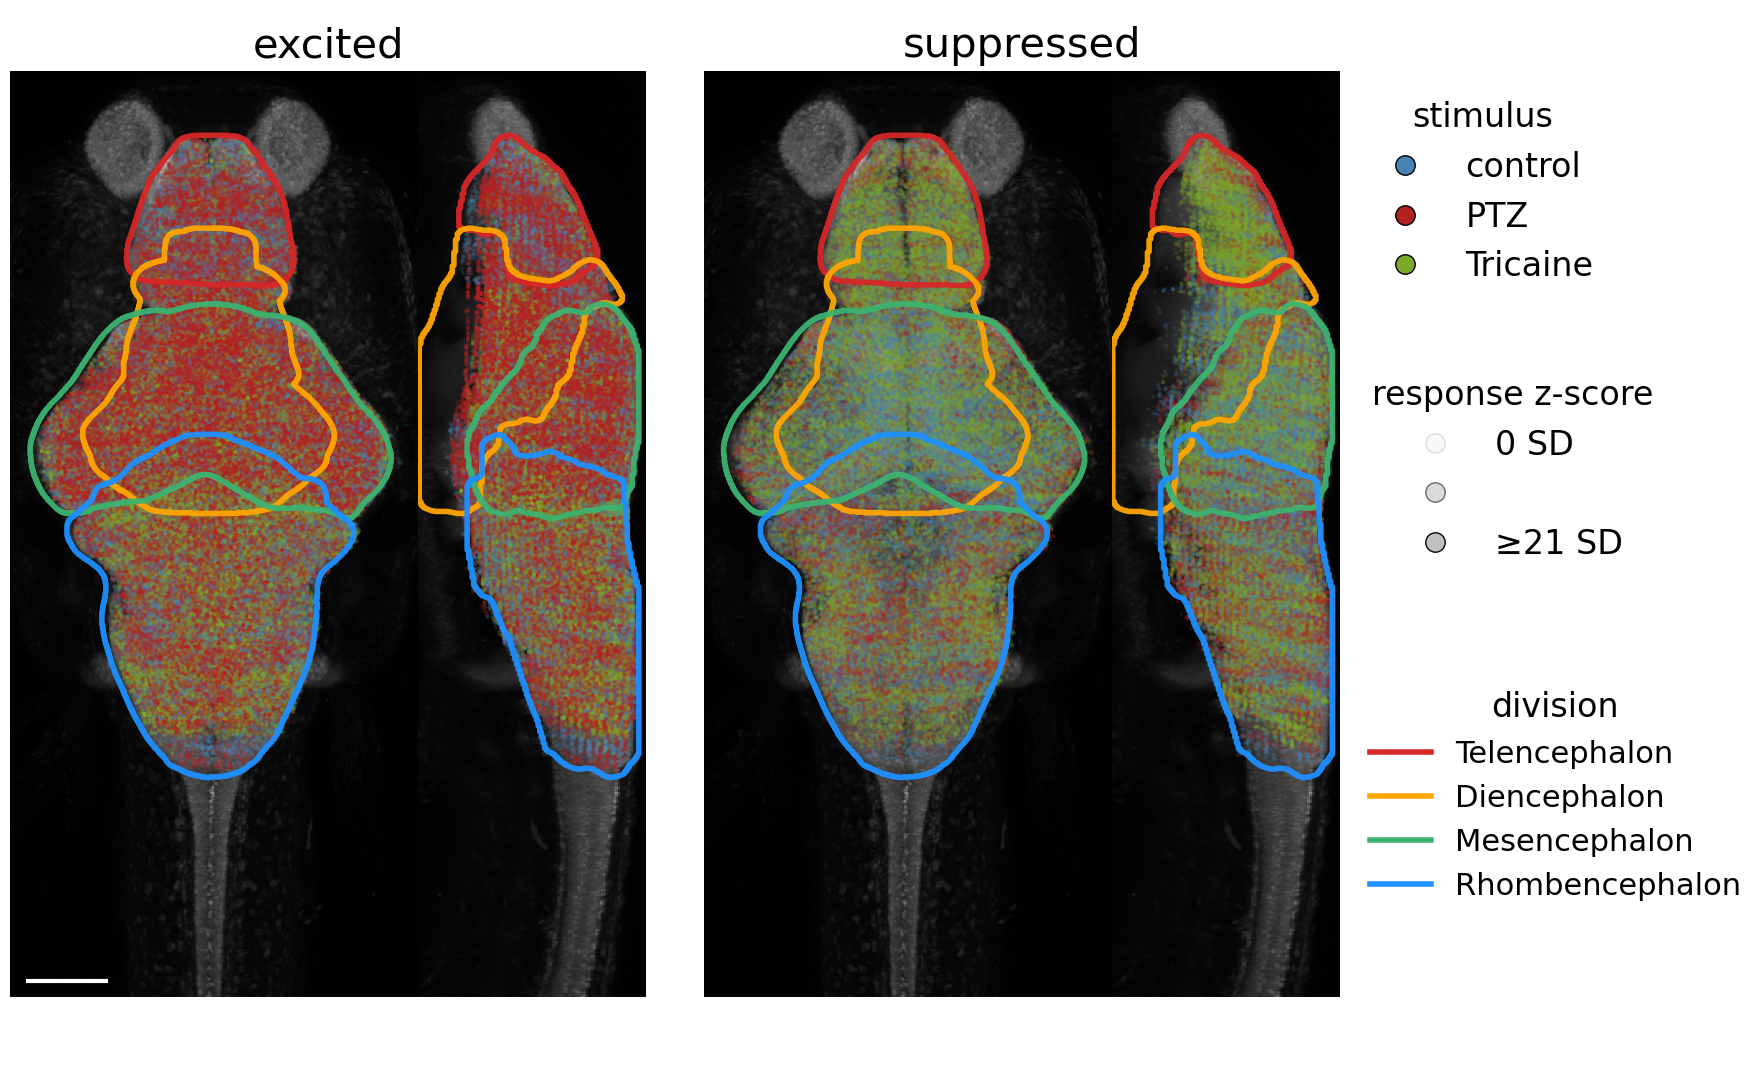

In [15]:
plot_selectivity_map(responsive, path_to_save=f'{outdir}/selectivity_map_{variant}')

### Co-active neuron map  
One representative fish per compound, neurons colored by their coactivity (correlation) with the mean population activity during stimulation

In [16]:
# with evoked=True color is given by coactivity during stimulus minus baseline coactivity, to visualize stimulus-driven change
def plot_coactivity_map(neurons, path_to_save=None, s=9, px_in=0.006, evoked=True):
    
    if evoked:
        neurons = neurons.assign(coactivity=neurons['coactivity'] - neurons['baseline_coact'])
        
    dots = neurons[neurons['coactivity'] >= coact_floor]
    dots = dots[[f == map_fish[c] for f, c in zip(dots['fish'], dots['compound'])]]
    vmax = float(np.percentile(dots['coactivity'], 99)) if len(dots) else 1.0
    norm = mcolors.Normalize(vmin=coact_floor, vmax=max(vmax, coact_floor + 1e-3))

    ylim = (dorsal.shape[0] - 1, 0)
    dorsal_xlim = (0, dorsal.shape[1] - 1)
    lateral_xlim = (0, lateral.shape[0] * zstretch)
    dw, lw, yh = pair_widths(dorsal, lateral)
    gap, cbar_w = 0.5 * (dw + lw) * 0.10, 0.5 * (dw + lw) * 0.05
    widths, pair_cols = [], []
    for _ in compounds:
        pair_cols.append(len(widths))
        widths += [dw, lw, gap]
    widths += [cbar_w]
    
    fig, axs = plt.subplots(1, len(widths), figsize=(sum(widths) * px_in, yh * px_in * 1.12),
                            gridspec_kw={'width_ratios': widths, 'wspace': 0.0})
    for k in range(len(widths)):
        if k not in pair_cols and k - 1 not in pair_cols:
            axs[k].set_axis_off()

    for i, compound in enumerate(compounds):
        c = dots[dots.compound == compound]
        print(f'{compound} ({map_fish[compound]}): n co-active = {len(c)}')
        for j, (view, xlim) in enumerate([('dorsal', dorsal_xlim), ('lateral', lateral_xlim)]):
            ax = axs[pair_cols[i] + j]
            draw_anatomy(ax, view, dorsal, lateral, div_masks, ylim, xlim,
                         scalebar=(i == 0 and j == 0))
            if len(c):
                d = c.iloc[np.argsort(c['coactivity'].to_numpy())]   # strong drawn on top
                v = np.clip(norm(d['coactivity'].to_numpy()), 0, 1)
                rgba = plt.get_cmap(coact_cmap)(v)
                rgba[:, 3] = 0.25 + 0.72 * v
                sx, sy = view_coords(view, d)
                ax.scatter(sx, sy, s=s, c=rgba, linewidths=0, marker='o',
                           rasterized=True, zorder=4)
            if j == 0:
                x_center = (dw + lw) / (2 * dw)
                ax.set_title(compound, x=x_center, fontsize=26)

    # colorbar
    key_ax = axs[-1]
    sm = cm.ScalarMappable(norm=norm, cmap=coact_cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=key_ax.inset_axes([0.0, 0.25, 2.5, 0.5]))
    cbar.set_label('stimulus-evoked co-activity' if evoked
                   else 'co-activity (r with population)', fontsize=24)
    cbar.ax.tick_params(labelsize=22)
    
    if path_to_save:
        fig.savefig(f'{path_to_save}.pdf', bbox_inches='tight', dpi=300)
        fig.savefig(f'{path_to_save}.png', bbox_inches='tight', dpi=200)
        
    return fig, axs

In [17]:
# per-fish summary of mean coactivity over all neurons and percentage of neurons above coact_floor
# both for raw coactivity and for the evoked (stimulus - baseline) coactivity
per_fish = (coactivity
            .assign(evoked=coactivity['coactivity'] - coactivity['baseline_coact'],
                    coact_pos=coactivity['coactivity'] >= coact_floor)
            .assign(evoked_pos=lambda d: d['evoked'] >= coact_floor)
            .groupby(['compound', 'fish'])
            .agg(mean_coact=('coactivity', 'mean'),
                 pct_coactive=('coact_pos', lambda s: 100.0 * s.mean()),
                 mean_evoked=('evoked', 'mean'),
                 pct_coactive_evoked=('evoked_pos', lambda s: 100.0 * s.mean()))
            .reset_index())
per_fish.to_csv(f'{outdir}/coactivity_per_fish_{variant}.csv', index=False)
per_fish

,compound,fish,mean_coact,pct_coactive,mean_evoked,pct_coactive_evoked
0,PTZ,fish04,0.415694,82.355926,0.245586,58.938021
1,PTZ,fish08,0.521977,85.664810,0.438152,79.491868
2,PTZ,fish09,0.584304,95.732671,0.438989,75.353998
3,PTZ,fish11,0.530059,85.757576,0.285448,60.342424
4,PTZ,fish12,0.462310,80.690414,0.229286,53.127187
5,Tricaine,fish02,0.420816,76.131724,0.228240,56.340058
6,Tricaine,fish04,0.303975,66.510376,0.042751,27.644724
7,Tricaine,fish06,0.224832,56.752407,0.060535,31.197573
8,Tricaine,fish07,0.221338,51.124761,-0.005999,24.149357
9,Tricaine,fish10,0.494684,93.521956,0.352573,75.087790


control (fish09): n co-active = 19150
PTZ (fish11): n co-active = 28300
Tricaine (fish02): n co-active = 25361


(<Figure size 1839.97x944.16 with 10 Axes>,
 array([<Axes: title={'center': 'control'}>, <Axes: >, <Axes: >,
        <Axes: title={'center': 'PTZ'}>, <Axes: >, <Axes: >,
        <Axes: title={'center': 'Tricaine'}>, <Axes: >, <Axes: >, <Axes: >],
       dtype=object))

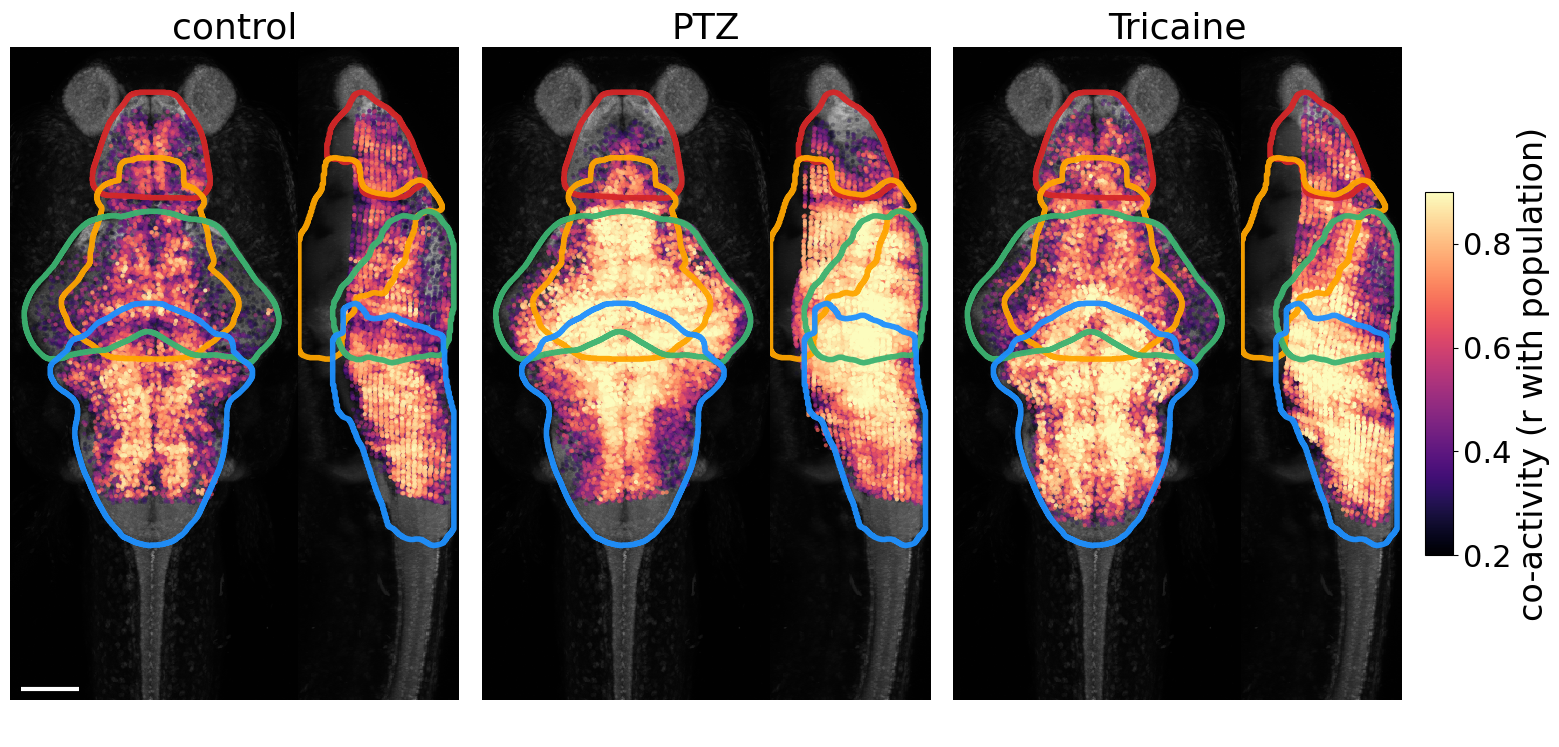

In [18]:
plot_coactivity_map(coactivity, path_to_save=f'{outdir}/coactive_neurons_map_{variant}', evoked=False)

control (fish09): n co-active = 9198
PTZ (fish11): n co-active = 19913
Tricaine (fish02): n co-active = 18768


(<Figure size 1839.97x944.16 with 10 Axes>,
 array([<Axes: title={'center': 'control'}>, <Axes: >, <Axes: >,
        <Axes: title={'center': 'PTZ'}>, <Axes: >, <Axes: >,
        <Axes: title={'center': 'Tricaine'}>, <Axes: >, <Axes: >, <Axes: >],
       dtype=object))

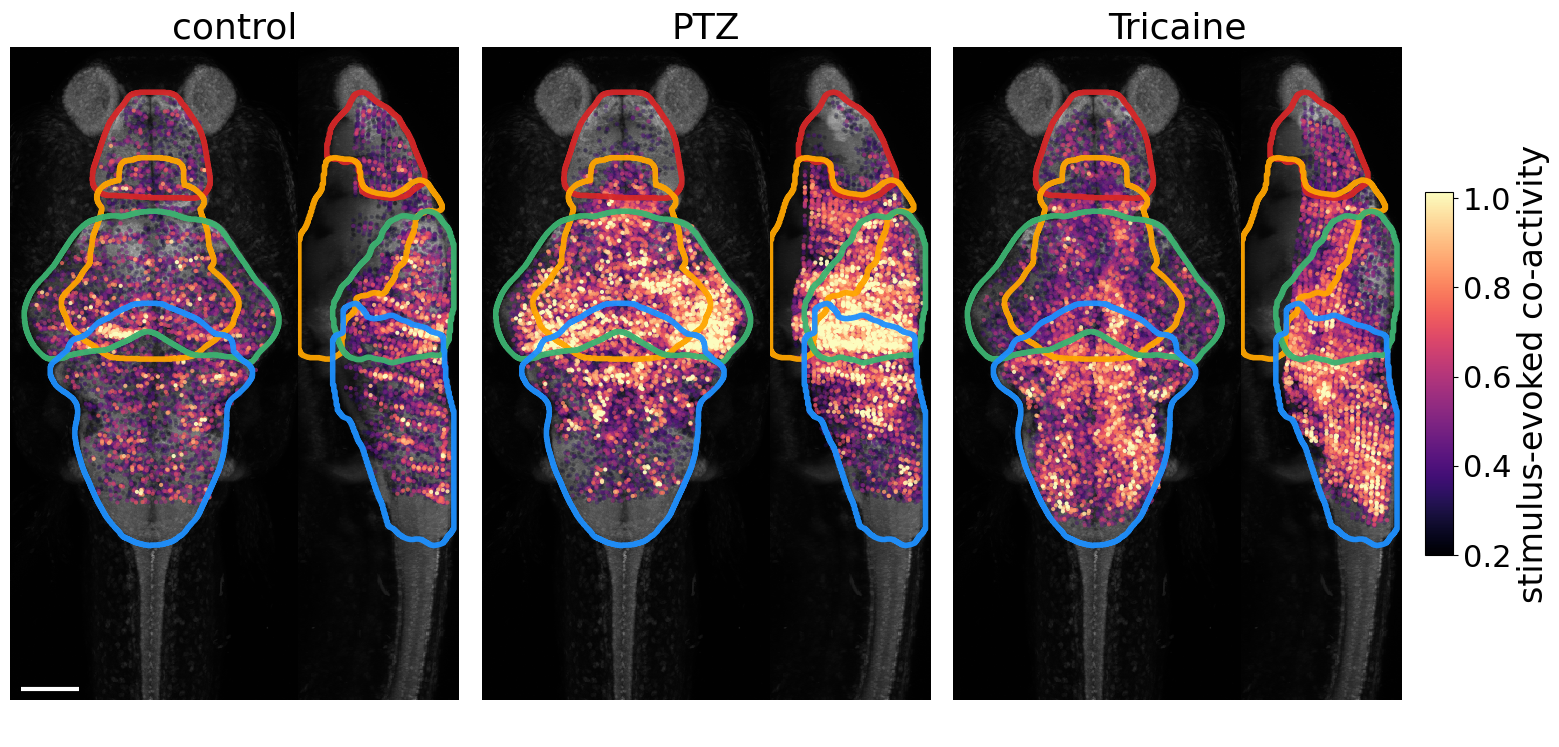

In [19]:
plot_coactivity_map(coactivity, path_to_save=f'{outdir}/coactive_neurons_map_evoked_{variant}', evoked=True)

### Tricaine emergence region fill map  
Regions ranked by their tricaine emergence index and top regions filled (with fill brightness proportional to emergence index)  
Emergence index is defined as the net rise (post-washout peak - pre-washout level) when the pre-washout activity was below zero and the post-washout peak is at least 2x above the baseline SD, otherwise it is set to zero. This gating excludes some posterior regions with larger net rise but not suppressed during the stimulus.

In [20]:
region_mask_cache = f'{outdir}/region_masks_dorsal_lateral.npz'

def load_region_projections(regions):

    regions = list(regions)
    cached = {}
    if os.path.exists(region_mask_cache):
        z = np.load(region_mask_cache, allow_pickle=True)
        cached = {r: (d, l) for r, d, l in zip(z['regions'], z['dorsal'], z['lateral'])}
        
    missing = [r for r in regions if r not in cached]
    for i, region in enumerate(missing):
        path = f'{zbrain_masks}/{region}.nrrd'
        if not os.path.exists(path):
            continue
        vol, _ = load_nrrd(path)
        b = vol > 0
        cached[region] = (shift_left(np.max(b, axis=0), mask_shift_x), np.max(b, axis=2))

    if any(r in cached for r in missing):
        np.savez_compressed(region_mask_cache,
                            regions=np.array(list(cached.keys())),
                            dorsal=np.stack([v[0] for v in cached.values()]),
                            lateral=np.stack([v[1] for v in cached.values()]))
        
    return {r: cached[r] for r in regions if r in cached}

In [21]:
def emergence_fill_image(view, region_projections, emergence, vmax, brain_dim=0.55):

    if view == 'dorsal':
        ref2d = dorsal
        masks = {r: pair[0] for r, pair in region_projections.items()}
    else:
        ref2d = lateral.T
        masks = {r: pair[1].T for r, pair in region_projections.items()}
        
    base = (ref2d * brain_dim)[..., None].repeat(3, axis=2).astype(np.float32)
    score = np.zeros(ref2d.shape, np.float32)
    alpha = np.zeros(ref2d.shape, np.float32)
    rgb = np.array(mcolors.to_rgb(colors['Tricaine']), np.float32)
    
    for region, e in emergence.items():
        m = masks.get(region)
        if m is None or not np.isfinite(e) or e <= 0:
            continue
        take = m & (e > score)
        score[take] = e
        alpha[take] = float(np.clip(e / vmax, 0, 1)) * 0.95
        
    return np.clip(base * (1 - alpha[..., None]) + rgb * alpha[..., None], 0, 1)

In [22]:
def plot_emergence_fill(emergence_df, top_n=emergence_top_n, path_to_save=None, px_in=0.0095):
    
    top = emergence_df.nlargest(top_n, 'emergence')
    emergence = dict(zip(top['region'], top['emergence']))
    positive = top.loc[top['emergence'] > 0, 'emergence'].to_numpy()
    vmax = float(np.percentile(positive, 95)) if positive.size else 1.0
    region_projections = load_region_projections(top['region'])

    ylim = (dorsal.shape[0] - 1, 0)
    dorsal_xlim = (0, dorsal.shape[1] - 1)
    lateral_xlim = (0, lateral.shape[0] * zstretch)
    dw, lw, yh = pair_widths(dorsal, lateral)
    
    fig, axs = plt.subplots(1, 2, figsize=((dw + lw) * px_in, yh * px_in * 1.1),
                            gridspec_kw={'width_ratios': [dw, lw], 'wspace': 0.0})
    
    img_d = emergence_fill_image('dorsal', region_projections, emergence, vmax)
    axs[0].imshow(img_d, extent=[-0.5, dorsal.shape[1] - 0.5, dorsal.shape[0] - 0.5, -0.5],
                  interpolation='nearest', aspect='equal', zorder=0)
    img_l = emergence_fill_image('lateral', region_projections, emergence, vmax)
    axs[1].imshow(img_l, extent=[-0.5, lateral.T.shape[1] * zstretch - 0.5, lateral.T.shape[0] - 0.5, -0.5],
                  interpolation='nearest', aspect='equal', zorder=0)
    
    for ax, view, xlim, scalebar in [(axs[0], 'dorsal', dorsal_xlim, True),
                                     (axs[1], 'lateral', lateral_xlim, False)]:
        # outlines and scale bar on top of the fill image
        draw_anatomy(ax, view, dorsal, lateral, div_masks, ylim, xlim, scalebar,
                     outline_lw=3.0, image=False)
    axs[0].set_title('dorsal', fontsize=30)
    axs[1].set_title('lateral', fontsize=30)

    cmap = mcolors.LinearSegmentedColormap.from_list(
        'tricaine_emergence', [(0.0, '0.12'), (1.0, colors['Tricaine'])])
    sm = cm.ScalarMappable(norm=mcolors.Normalize(0, vmax), cmap=cmap)
    cbar = fig.colorbar(sm, cax=axs[1].inset_axes([1.1, 0.25, 0.15, 0.5]))
    cbar.set_label('emergence index', fontsize=28)
    cbar.ax.tick_params(labelsize=26)

    if path_to_save:
        fig.savefig(f'{path_to_save}.pdf', bbox_inches='tight', dpi=300)
        fig.savefig(f'{path_to_save}.png', bbox_inches='tight', dpi=200)
        
    return fig, axs

In [23]:
# select only regions with enough neurons to trust the recovery metrics
tricaine_counts = (region_counts[region_counts['compound'] == 'Tricaine']
                   .groupby('group')['n_neurons'].median())
well_sampled = set(tricaine_counts[tricaine_counts >= min_neurons_per_region].index)

In [24]:
emergence_ok = emergence_map[emergence_map['region'].isin(well_sampled)]

In [25]:
emergence_ok.head(emergence_top_n)[['region', 'emergence', 'ci_lo', 'ci_hi', 'n_fish']].round(3)

,region,emergence,ci_lo,ci_hi,n_fish
0,Telencephalon - Vmat2 cluster,0.505,0.421,0.589,5
1,Telencephalon - Olfactory bulb dopaminergic ne...,0.501,0.439,0.573,5
2,Telencephalon - Subpallial dopaminergic cluster,0.406,0.286,0.525,5
3,Telencephalon - Subpallial Gad1b cluster,0.388,0.332,0.451,5
4,Telencephalon - Subpallium,0.367,0.317,0.429,5
5,Telencephalon - Olfactory Bulb,0.356,0.242,0.437,5
6,Diencephalon - Left Habenula Vglut2 Cluster,0.344,0.242,0.447,5
7,Diencephalon - Right Habenula Vglut2 Cluster,0.340,0.280,0.381,5
8,Telencephalon - Telencephalic Migrated Area 4 ...,0.338,0.242,0.451,5
9,Telencephalon - Isl1 cluster 1,0.320,0.151,0.451,5


(<Figure size 917.571x1468.23 with 2 Axes>,
 array([<Axes: title={'center': 'dorsal'}>,
        <Axes: title={'center': 'lateral'}>], dtype=object))

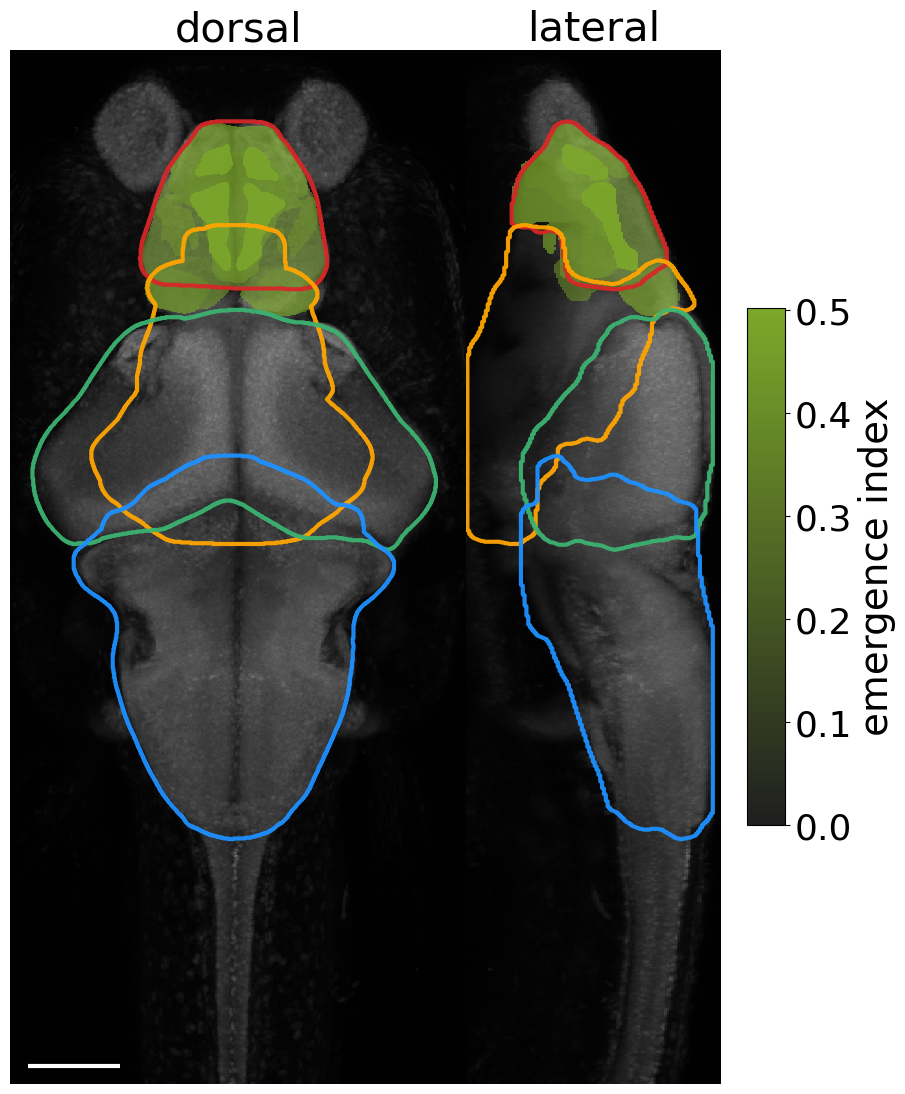

In [26]:
plot_emergence_fill(emergence_ok, path_to_save=f'{outdir}/tricaine_emergence_fill_top{emergence_top_n}_{variant}')

### Tricaine response z-score map
Tricaine responsive neurons from all fish colored by their z-scored response strength (red excited, blue suppressed).  
Response z-score defined as (mean stimulus dFF - mean baseline dFF) / baseline SD.

In [27]:
def plot_tricaine_zscore_map(tri, path_to_save=None, s=7, px_in=0.011, seed=0):
    vmax = float(np.percentile(tri['resp_z'].abs(), effect_vmax_pct)) if len(tri) else 8.0
    norm = mcolors.Normalize(-vmax, vmax)

    ylim = (dorsal.shape[0] - 1, 0)
    dorsal_xlim = (0, dorsal.shape[1] - 1)
    lateral_xlim = (0, lateral.shape[0] * zstretch)
    dw, lw, yh = pair_widths(dorsal, lateral)
    
    fig, axs = plt.subplots(1, 2, figsize=((dw + lw) * px_in, yh * px_in * 1.14),
                            gridspec_kw={'width_ratios': [dw, lw], 'wspace': 0.0})
    for ax, view, xlim, scalebar in [(axs[0], 'dorsal', dorsal_xlim, True),
                                     (axs[1], 'lateral', lateral_xlim, False)]:
        draw_anatomy(ax, view, dorsal, lateral, div_masks, ylim, xlim, scalebar,
                     outline_lw=3.0)
        if len(tri):
            d = tri.iloc[np.random.default_rng(seed).permutation(len(tri))]
            rgba = plt.get_cmap(effect_cmap)(norm(d['resp_z'].to_numpy(float))).astype(np.float32)
            rgba[:, 3] = effect_alpha
            sx, sy = view_coords(view, d)
            ax.scatter(sx, sy, s=s, c=rgba, linewidths=0, marker='o', rasterized=True, zorder=4)
            
    n_up, n_down = int(tri['up'].sum()), int(tri['down'].sum())
    axs[0].set_title('dorsal', fontsize=30)
    axs[1].set_title('lateral', fontsize=30)
    sm = cm.ScalarMappable(norm=norm, cmap=effect_cmap)
    cbar = fig.colorbar(sm, cax=axs[1].inset_axes([1.1, 0.25, 0.15, 0.5]))
    cbar.set_label('response z-score', fontsize=28)
    cbar.ax.tick_params(labelsize=26)

    if path_to_save:
        fig.savefig(f'{path_to_save}.pdf', bbox_inches='tight', dpi=300)
        fig.savefig(f'{path_to_save}.png', bbox_inches='tight', dpi=200)
        
    return fig, axs

(<Figure size 1062.45x1761.87 with 2 Axes>,
 array([<Axes: title={'center': 'dorsal'}>,
        <Axes: title={'center': 'lateral'}>], dtype=object))

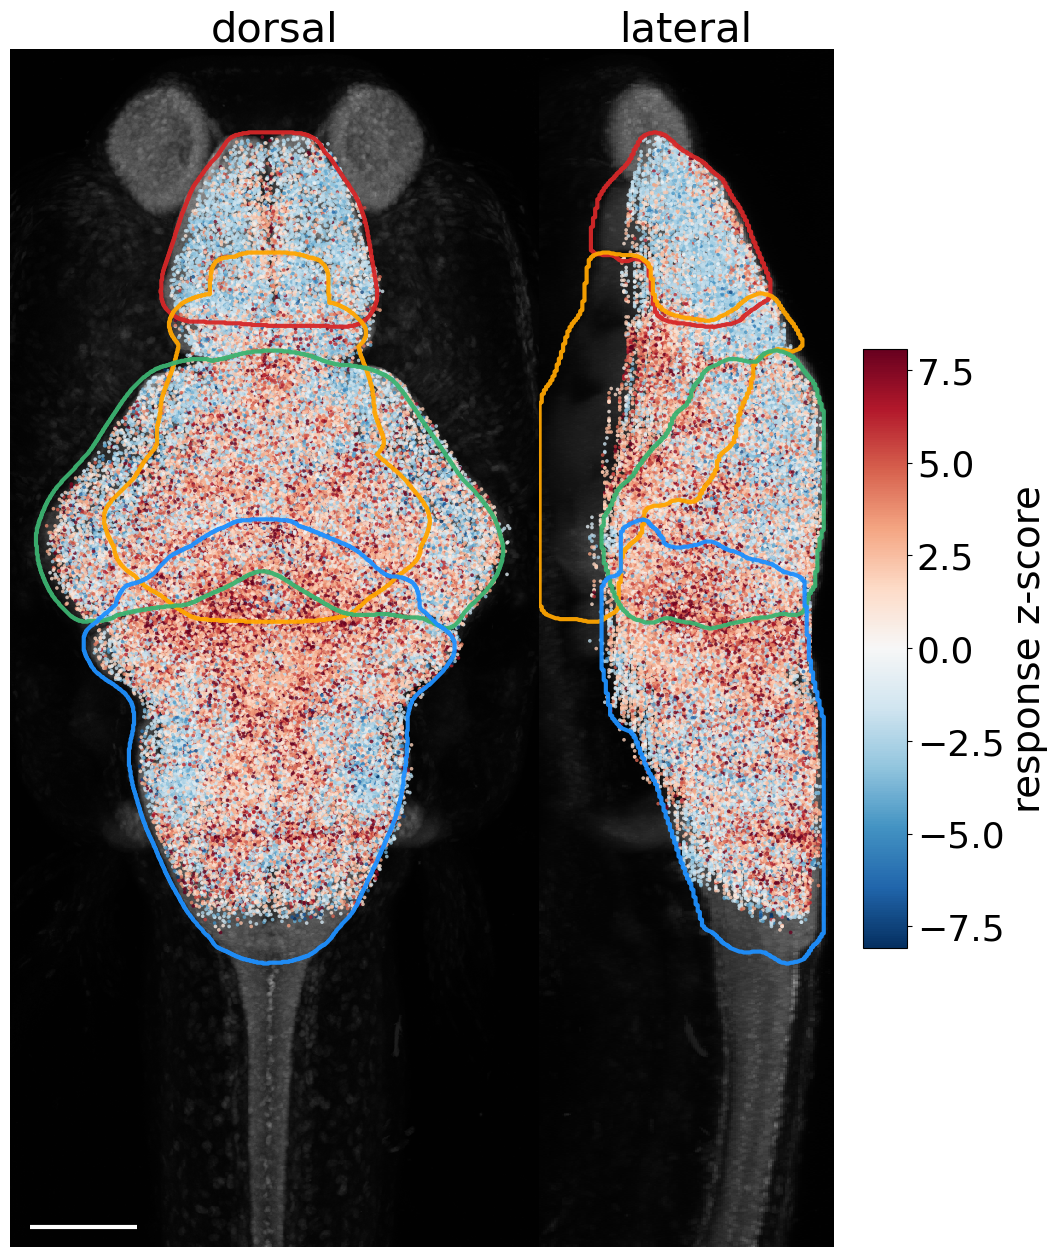

In [28]:
tricaine_neurons = responsive[responsive.compound == 'Tricaine']
plot_tricaine_zscore_map(tricaine_neurons, path_to_save=f'{outdir}/tricaine_neurons_response_zscore_{variant}')

In [29]:
rows = []
for division in division_colors:
    vol, _ = load_nrrd(f'{zbrain_masks}/{division} -.nrrd')
    m = np.max(vol > 0, axis=0)                          # (y, x), unshifted like the cells
    xi = np.clip(tricaine_neurons['x'].to_numpy().astype(int), 0, m.shape[1] - 1)
    yi = np.clip(tricaine_neurons['y'].to_numpy().astype(int), 0, m.shape[0] - 1)
    d = tricaine_neurons[m[yi, xi]]
    if len(d):
        rows.append({'division': division, 'n': len(d), 
                     'n_up': int(d['up'].sum()),
                     'pct_up': round(100 * float(d['up'].mean()), 1),
                     'n_down': int(d['down'].sum()),
                     'pct_down': round(100 * float(d['down'].mean()), 1),
                     'mean_response': round(float(d['resp_z'].mean()), 2),
                     'median_response': round(float(d['resp_z'].median()), 2)})
updown_summary = pd.DataFrame(rows)
updown_summary.to_csv(f'{outdir}/tricaine_division_updown_{variant}.csv', index=False)
updown_summary

,division,n,n_up,pct_up,n_down,pct_down,mean_response,median_response
0,Telencephalon,8070,2365,29.3,5705,70.7,-0.99,-2.01
1,Diencephalon,45256,30039,66.4,15217,33.6,1.72,1.92
2,Mesencephalon,44629,29263,65.6,15366,34.4,1.56,1.81
3,Rhombencephalon,52915,38444,72.7,14471,27.3,2.29,2.22
